In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Style sạch, đẹp cho báo cáo
sns.set_palette("muted")

# Đọc dữ liệu (Đường dẫn tương tự Question 01)
try:
    df = pd.read_csv('../../data/processed/clean_data.csv') # Cập nhật đường dẫn đúng của bạn
except FileNotFoundError:
    df = pd.read_csv('clean_data.csv') # Fallback nếu file ở cùng thư mục

# Kiểm tra nhanh dữ liệu
print(f"Dữ liệu đã load: {df.shape}")
display(df.head(2))

Dữ liệu đã load: (28554, 34)


,price,area,district,ward,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,...,lock_type,wc_type,water_type,area_group,price_per_sqm,amenity_score,location_score,has_private_facilities,security_score,log_price
0,5500000.0,30.0,tân bình,4,True,True,True,True,True,True,...,fingerprint,unknown,unknown,near_center,183333.333333,9,0,0,3,15.520259
1,3500000.0,26.0,tân bình,2,False,False,False,False,False,False,...,unknown,unknown,bottle,near_center,134615.384615,3,1,0,1,15.068274


# Question 05: Định giá "Sự tiện nghi" - Tiện ích nào đang bị "thổi giá"?

## 1. Đặt vấn đề
Một câu hỏi kinh điển của người đi thuê: *"Thêm cái máy lạnh thì giá phòng đắt hơn bao nhiêu?"* hay *"Phòng full nội thất có thực sự hời hơn phòng trống?"*.

Chúng ta sẽ đi tìm **"Premium Price"** (Giá trị gia tăng) của từng tiện ích bằng cách so sánh chênh lệch giá trung bình giữa các phòng **CÓ** và **KHÔNG** có tiện ích đó.

## 2. Phương pháp phân tích
* **Bước 1:** Lọc các biến định danh tiện ích (các cột bắt đầu bằng `has_`, `is_`).
* **Bước 2:** Với mỗi tiện ích, tính giá trung bình của 2 nhóm: Nhóm sở hữu (True) và Nhóm không sở hữu (False).
* **Bước 3:** Tính chênh lệch giá (Gap) và tỷ lệ tăng giá (Percentage Increase).
* **Bước 4:** Xếp hạng các tiện ích đắt đỏ nhất.

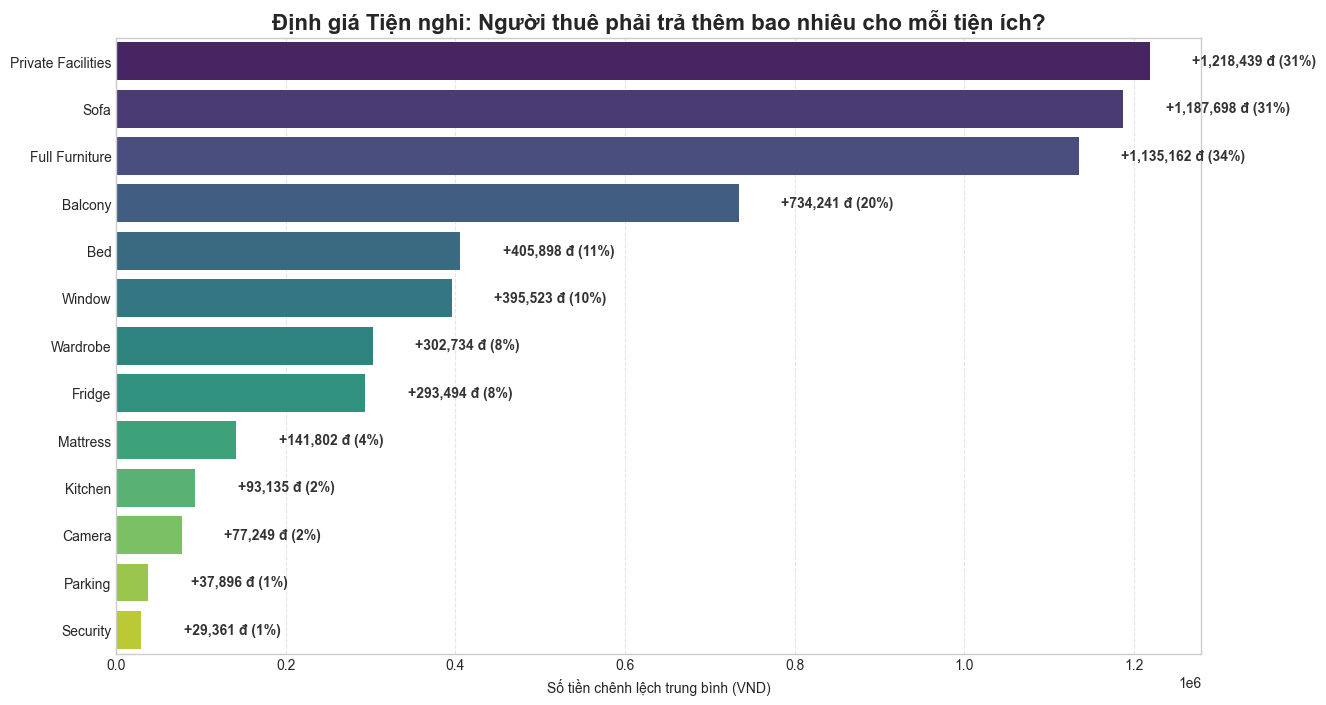

💡 Insight: Ba tiện ích làm tăng giá phòng nhiều nhất là: Private Facilities, Sofa, Full Furniture.


In [4]:
# --- PHÂN TÍCH GIÁ TRỊ GIA TĂNG CỦA TIỆN ÍCH ---

# 1. Xác định các cột tiện ích (Boolean features)
# Dựa trên dữ liệu mẫu của bạn, các cột thường bắt đầu bằng 'has_' hoặc 'is_'
amenity_cols = [col for col in df.columns if col.startswith(('has_', 'is_'))]

premium_data = []

for col in amenity_cols:
    # Gom nhóm và tính giá trung bình
    if df[col].nunique() >= 2: # Chỉ xét nếu có đủ 2 trạng thái True/False
        grouped = df.groupby(col)['price'].mean()
        
        # Đảm bảo index 0 là False/0 và 1 là True/1 để trừ đúng chiều
        try:
            price_no = grouped[0]
            price_yes = grouped[1]
            
            diff = price_yes - price_no
            percent = (diff / price_no) * 100
            
            # Chỉ lấy các tiện ích làm TĂNG giá để phân tích (diff > 0)
            if diff > 0:
                # Làm đẹp tên cột (vd: has_air_conditioner -> Air Conditioner)
                readable_name = col.replace('has_', '').replace('is_', '').replace('_', ' ').title()
                
                premium_data.append({
                    'Tiện ích': readable_name,
                    'Giá chênh lệch (VND)': diff,
                    'Tăng trưởng (%)': percent
                })
        except KeyError:
            continue

# 2. Tạo DataFrame kết quả và Sắp xếp
df_premium = pd.DataFrame(premium_data).sort_values(by='Giá chênh lệch (VND)', ascending=False)

# 3. Trực quan hóa Top Tiện ích "Đắt giá" nhất
plt.figure(figsize=(14, 8))
barplot = sns.barplot(
    y='Tiện ích', 
    x='Giá chênh lệch (VND)', 
    data=df_premium, 
    palette='viridis'
)

# Thêm nhãn giá trị chi tiết
for i, p in enumerate(barplot.patches):
    width = p.get_width()
    percent = df_premium.iloc[i]['Tăng trưởng (%)']
    plt.text(
        width + 50000,  # Vị trí x (dịch sang phải chút cho đỡ dính)
        p.get_y() + p.get_height()/2, 
        f"+{width:,.0f} đ ({percent:.0f}%)", 
        va='center', fontweight='bold', color='#333333'
    )

plt.title('Định giá Tiện nghi: Người thuê phải trả thêm bao nhiêu cho mỗi tiện ích?', fontsize=16, fontweight='bold')
plt.xlabel('Số tiền chênh lệch trung bình (VND)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# In Top 3 tiện ích đắt nhất
top_3 = df_premium.head(3)['Tiện ích'].tolist()
print(f"💡 Insight: Ba tiện ích làm tăng giá phòng nhiều nhất là: {', '.join(top_3)}.")